In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


In [3]:

# Percorso base
base_path = Path(r"T:\Aet\Private\MAP\MPF\WES\00_data\aci")

# Cartella di output (nella stessa cartella di lavoro del notebook)
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

# Ciclo su tutte le cartelle RW_*
for rw_dir in base_path.glob("RW_*"):
    print(f"Elaboro: {rw_dir.name}")

    # Trova CSV e TXT
    csv_file = list(rw_dir.glob("*.csv"))[0]
    txt_file = list(rw_dir.glob("*.txt"))[0]

    # -----------------------
    # Leggo il CSV
    # -----------------------
    df = pd.read_csv(csv_file)

    # Rinomino colonne per comodità
    df.columns = ["Id_Sensore", "Data_Ora", "Valore_Cumulato"]

    # Converto la data
    df["Data_Ora"] = pd.to_datetime(df["Data_Ora"], format="%Y/%m/%d %H:%M")

    # Sostituisco i valori non validi
    df["Valore_Cumulato"] = df["Valore_Cumulato"].replace(-999, np.nan)

    # -----------------------
    # Leggo il nome stazione dal TXT
    # -----------------------
    with open(txt_file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # Penultima riga
    penultima = lines[-2].strip()
    # separata da virgola → seconda colonna
    stazione = penultima.split(",")[1].strip()

    # -----------------------
    # Calcolo cumulata mensile
    # -----------------------
    df["AnnoMese"] = df["Data_Ora"].dt.to_period("M")
    monthly = df.groupby("AnnoMese")["Valore_Cumulato"].sum(min_count=1)
    monthly.index = monthly.index.to_timestamp()

    # -----------------------
    # Plot
    # -----------------------
    plt.figure(figsize=(12, 6))
    plt.plot(monthly.index, monthly.values)
    plt.title(f"Precipitazione cumulata mensile - {stazione}")
    plt.xlabel("Tempo")
    plt.ylabel("Precipitazione cumulata [mm]")
    plt.grid(True)

    # Nome file sicuro
    safe_station_name = stazione.replace(" ", "_").replace("/", "_")
    out_png = output_dir / f"{safe_station_name}_precipitazione_mensile.png"

    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"  Salvato: {out_png}")


Elaboro: RW_20250917114305_714229
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output\Idro_Frana_precipitazione_mensile.png
Elaboro: RW_20250919110311_714516
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output\Bagolino_SP669_precipitazione_mensile.png
Elaboro: RW_20250922114304_714797
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output\Brescia_ITAS_Pastori_precipitazione_mensile.png
Elaboro: RW_20260108163806_735720
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output\Sarezzo_v.della_Fonte_precipitazione_mensile.png
Elaboro: RW_20260108163816_735721
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output\Tavernole_sul_Mella_Monte_Guglielmo_precipitazione_mensile.png
Elaboro: RW_20260108164315_735723
 

In [6]:
# Percorso base
base_path = Path(r"T:\Aet\Private\MAP\MPF\WES\00_data\aci")

# Cartella di output per la climatologia mensile
clim_dir = Path.cwd() / "output_climatologia_mensile"
clim_dir.mkdir(exist_ok=True)

mesi = ["Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
        "Lug", "Ago", "Set", "Ott", "Nov", "Dic"]

for rw_dir in base_path.glob("RW_*"):
    print(f"Climatologia mensile: {rw_dir.name}")

    csv_file = list(rw_dir.glob("*.csv"))[0]
    txt_file = list(rw_dir.glob("*.txt"))[0]

    # -----------------------
    # Lettura CSV
    # -----------------------
    df = pd.read_csv(csv_file)
    df.columns = ["Id_Sensore", "Data_Ora", "Valore_Cumulato"]

    df["Data_Ora"] = pd.to_datetime(df["Data_Ora"], format="%Y/%m/%d %H:%M")
    df["Valore_Cumulato"] = df["Valore_Cumulato"].replace(-999, np.nan)
    df = df.dropna(subset=["Valore_Cumulato"])

    if df.empty:
        print("  Nessun dato valido, salto.")
        continue

    # -----------------------
    # Cumulata mensile (Anno-Mese)
    # -----------------------
    df["AnnoMese"] = df["Data_Ora"].dt.to_period("M")
    monthly = df.groupby("AnnoMese")["Valore_Cumulato"].sum(min_count=1)
    monthly = monthly.to_timestamp()

    monthly_df = monthly.reset_index()
    monthly_df.columns = ["Data", "Precipitazione_Mensile"]
    monthly_df["Mese"] = monthly_df["Data"].dt.month
    monthly_df["Anno"] = monthly_df["Data"].dt.year

    # -----------------------
    # Climatologia: media per mese dell'anno
    # -----------------------
    clim = monthly_df.groupby("Mese")["Precipitazione_Mensile"].mean()

    # Riordino da 1 a 12 ed eventualmente riempio mesi mancanti con NaN
    clim = clim.reindex(range(1, 13))

    # -----------------------
    # Periodo storico
    # -----------------------
    start_year = monthly_df["Anno"].min()
    end_year = monthly_df["Anno"].max()

    # -----------------------
    # Nome stazione
    # -----------------------
    with open(txt_file, "r", encoding="utf-8") as f:
        lines = f.readlines()

    penultima = lines[-2].strip()
    stazione = penultima.split(",")[1].strip()

    # -----------------------
    # Plot climatologico
    # -----------------------
    plt.figure(figsize=(12, 6))
    plt.bar(mesi, clim.values)
    plt.xlabel("Mese")
    plt.ylabel("Precipitazione media mensile [mm]")
    plt.title(
        f"Climatologia delle precipitazioni mensili - {stazione}\n"
        f"Periodo: {start_year}–{end_year}"
    )
    plt.grid(axis="y")

    # Nome file sicuro
    safe_station_name = stazione.replace(" ", "_").replace("/", "_")
    out_png = clim_dir / f"{safe_station_name}_climatologia_mensile.png"

    # Salvataggio senza visualizzazione
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"  Salvato: {out_png}")

Climatologia mensile: RW_20250917114305_714229
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output_climatologia_mensile\Idro_Frana_climatologia_mensile.png
Climatologia mensile: RW_20250919110311_714516
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output_climatologia_mensile\Bagolino_SP669_climatologia_mensile.png
Climatologia mensile: RW_20250922114304_714797
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output_climatologia_mensile\Brescia_ITAS_Pastori_climatologia_mensile.png
Climatologia mensile: RW_20260108163806_735720
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\GitHub\a2a_WES\dashboard_pluvio_copy\output_climatologia_mensile\Sarezzo_v.della_Fonte_climatologia_mensile.png
Climatologia mensile: RW_20260108163816_735721
  Salvato: c:\Users\michele.giurato\OneDrive - A2A Group\Documenti\G

Salvata serie Febbraio 2004 per: Brescia ITAS Pastori (4176 record)


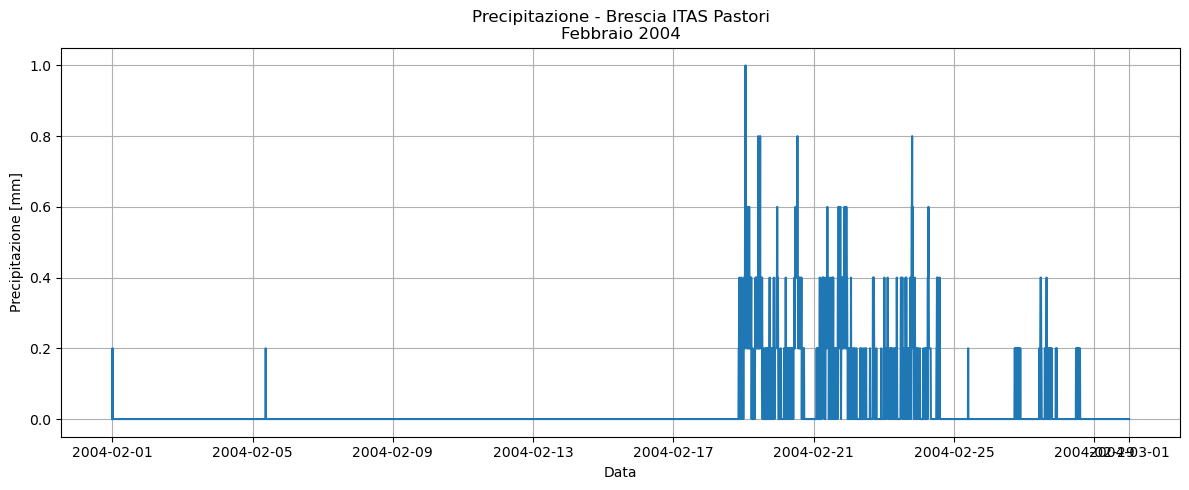

Salvata serie Febbraio 2004 per: Caino (1296 record)


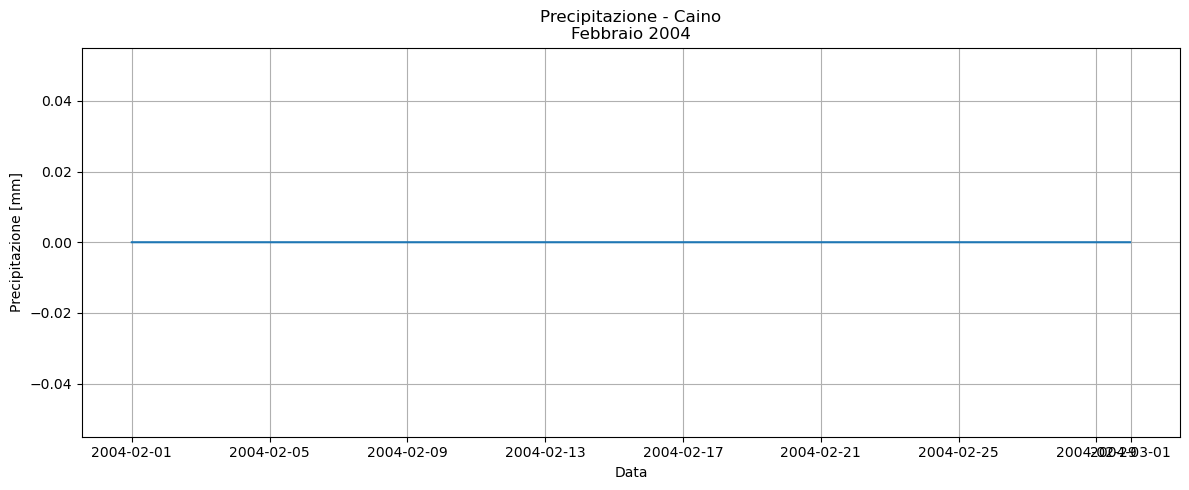

Salvata serie Febbraio 2004 per: Bovegno ponte Zigole (1344 record)


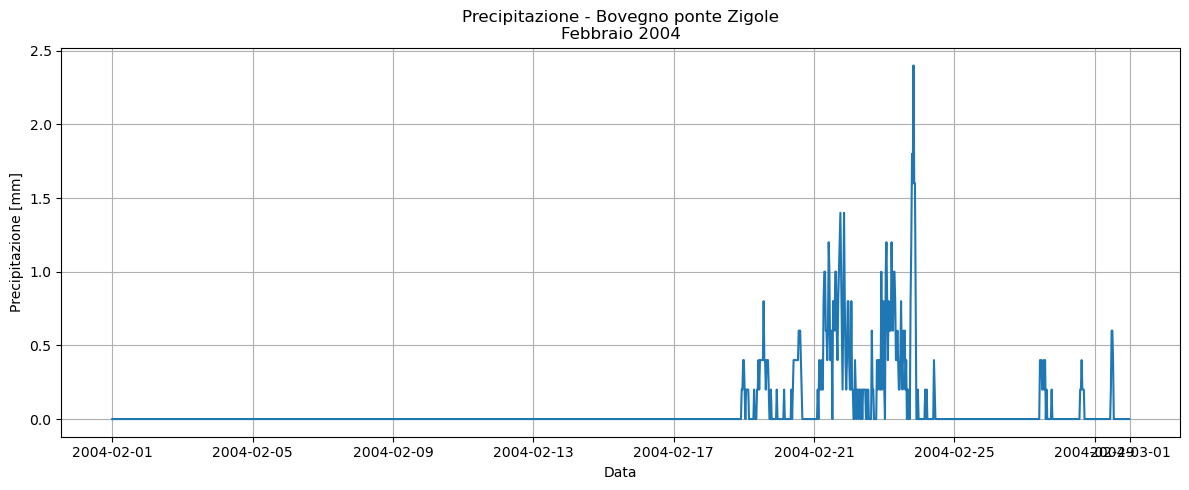

Salvata serie Febbraio 2004 per: Pisogne (1340 record)


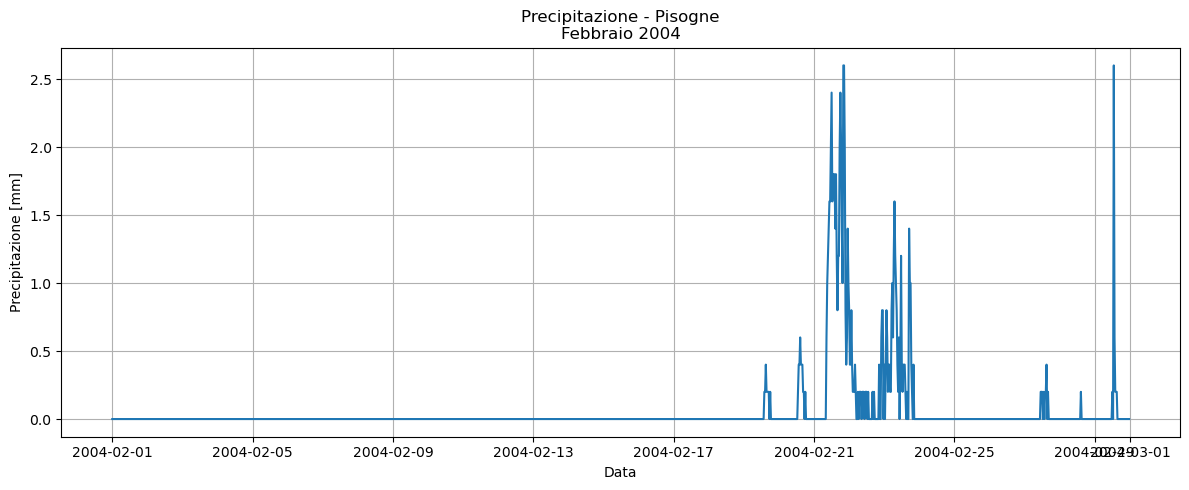

Salvata serie Febbraio 2004 per: Brescia v.Ziziola (517 record)


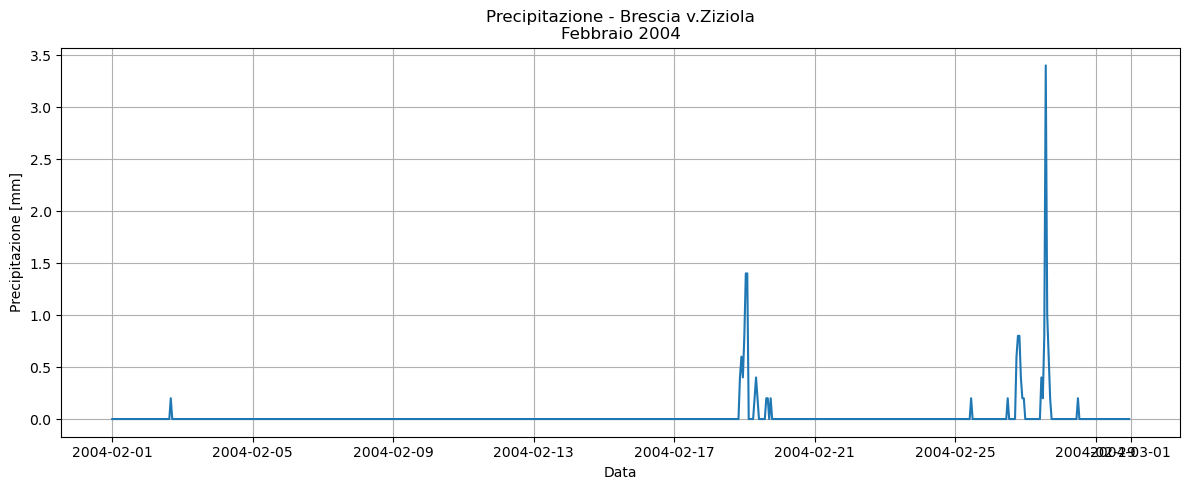

Salvata serie Febbraio 2004 per: Chiari (4176 record)


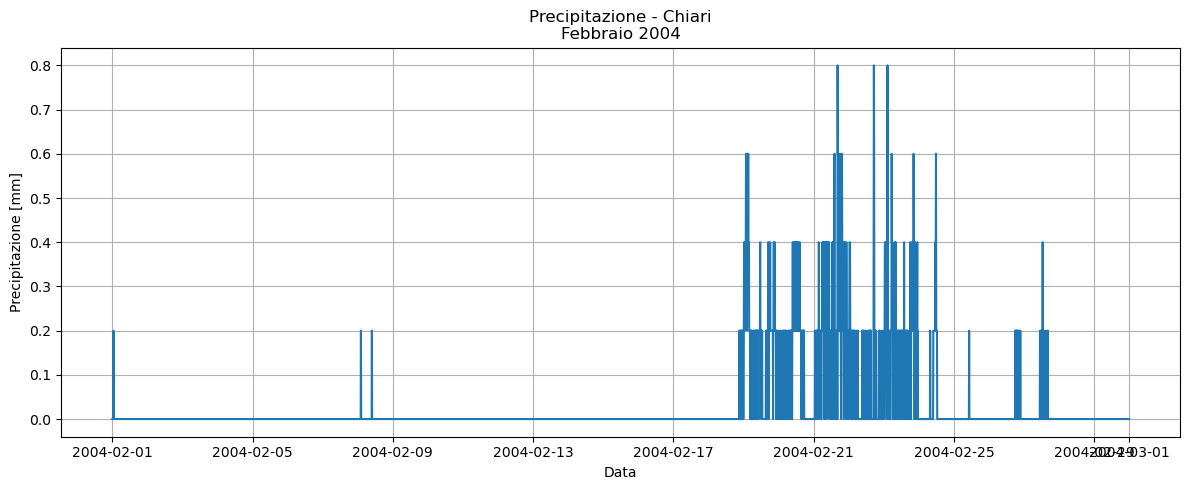

Salvata serie Febbraio 2004 per: Soncino v. Brescia (4174 record)


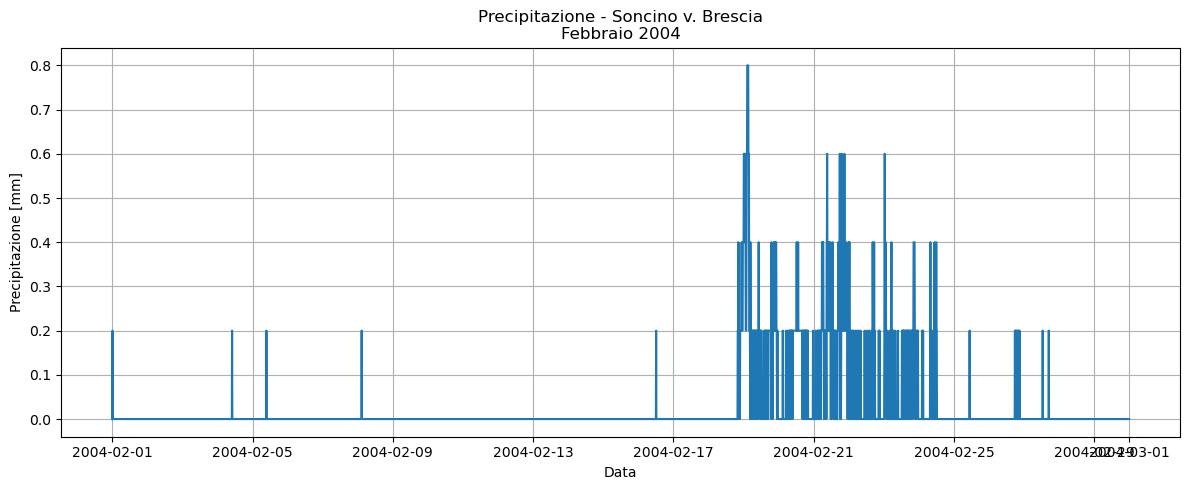

Salvata serie Febbraio 2004 per: Corzano Bargnano (4176 record)


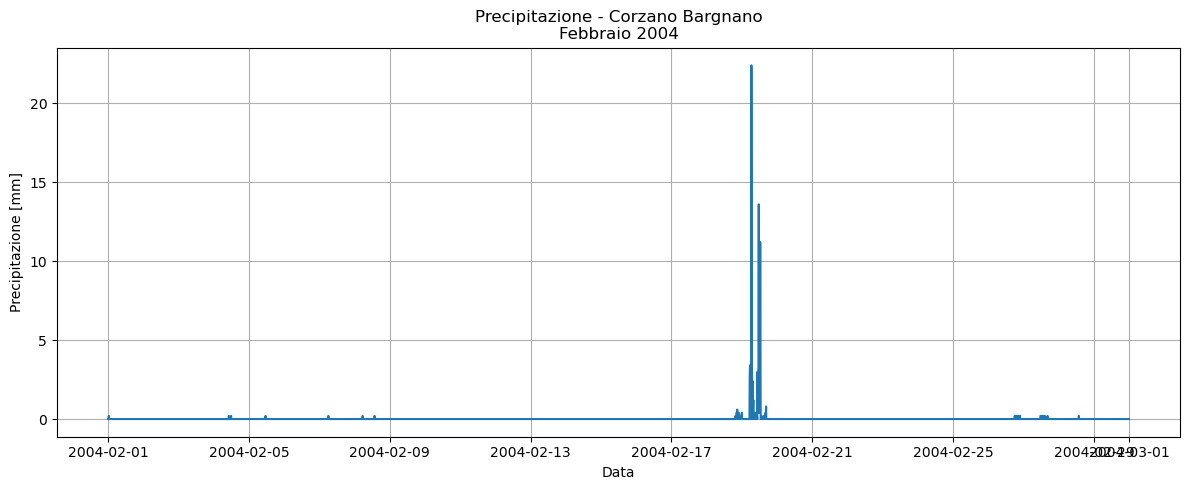

Salvata serie Febbraio 2004 per: Manerbio v.Dante (4174 record)


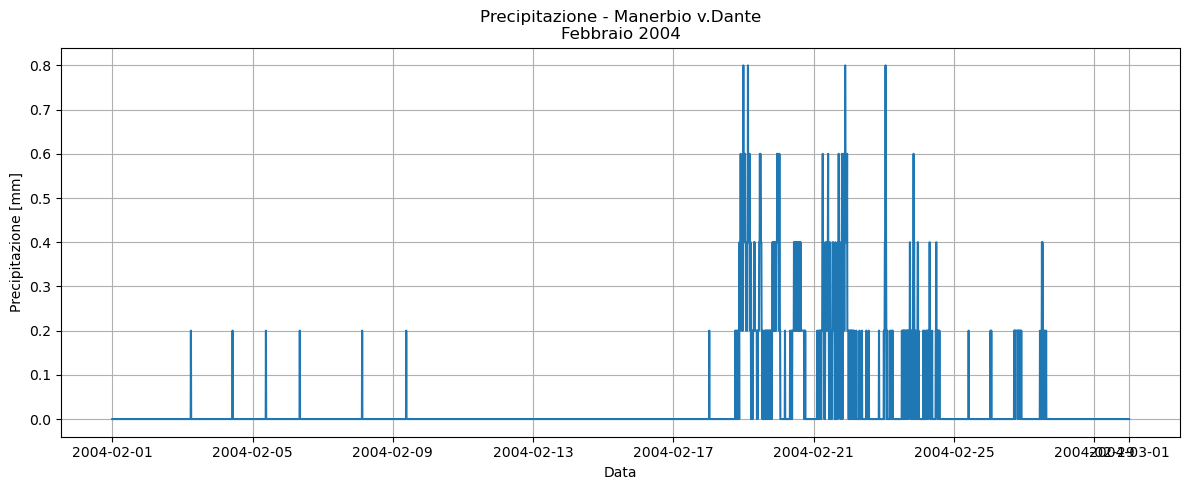

Salvata serie Febbraio 2004 per: Gambara v.Parma (696 record)


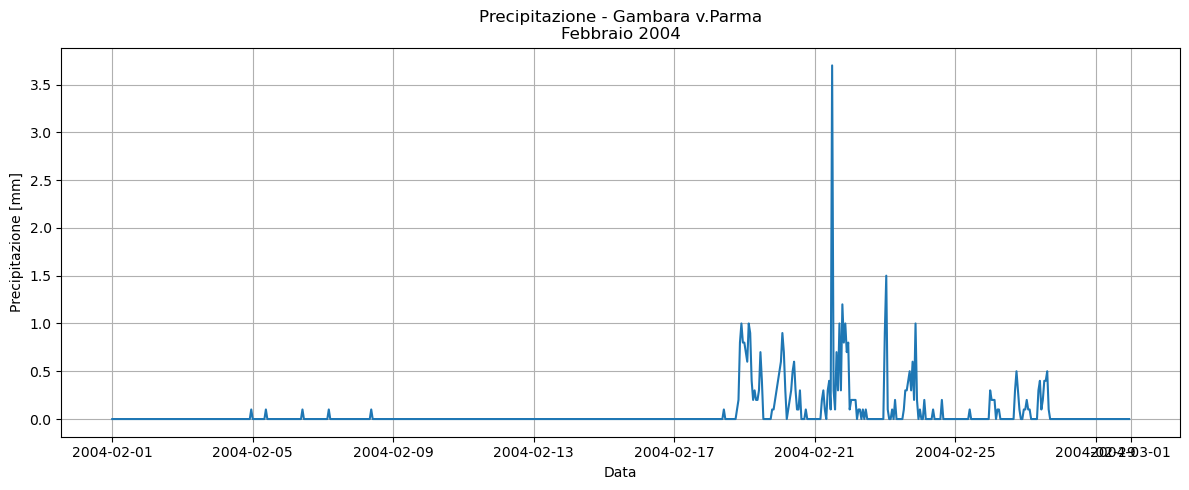

In [9]:
base_path = Path(r"T:\Aet\Private\MAP\MPF\WES\00_data\aci")

# Dizionario che conterrà SOLO le serie di Febbraio 2004
serie_feb_2004 = {}

for rw_dir in base_path.glob("RW_*"):

    csv_file = list(rw_dir.glob("*.csv"))[0]
    txt_file = list(rw_dir.glob("*.txt"))[0]

    # -----------------------
    # Nome stazione
    # -----------------------
    with open(txt_file, "r", encoding="utf-8") as f:
        lines = f.readlines()
    penultima = lines[-2].strip()
    stazione = penultima.split(",")[1].strip()

    # -----------------------
    # Lettura CSV
    # -----------------------
    df = pd.read_csv(csv_file)
    df.columns = ["Id_Sensore", "Data_Ora", "Valore_Cumulato"]

    df["Data_Ora"] = pd.to_datetime(df["Data_Ora"], format="%Y/%m/%d %H:%M")
    df["Valore_Cumulato"] = df["Valore_Cumulato"].replace(-999, np.nan)
    df = df.sort_values("Data_Ora")

    # -----------------------
    # Selezione Febbraio 2004
    # -----------------------
    mask = (
        (df["Data_Ora"].dt.year == 2004) &
        (df["Data_Ora"].dt.month == 2)
    )
    df_feb = df.loc[mask].dropna(subset=["Valore_Cumulato"])

    # Salvo solo se ci sono dati
    if not df_feb.empty:
        serie_feb_2004[stazione] = df_feb
        print(f"Salvata serie Febbraio 2004 per: {stazione} ({len(df_feb)} record)")

        # -----------------------
        # Plot time series
        # -----------------------
        plt.figure(figsize=(12, 5))
        plt.plot(df_feb["Data_Ora"], df_feb["Valore_Cumulato"])
        plt.title(f"Precipitazione - {stazione}\nFebbraio 2004")
        plt.xlabel("Data")
        plt.ylabel("Precipitazione [mm]")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

In [2]:
import plotly.io as pio
pio.renderers.default = "browser"


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

base_path = Path(r"T:\Aet\Private\MAP\MPF\WES\00_data\aci")

serie_stazioni = {}

for rw_dir in base_path.glob("RW_*"):

    csv_file = list(rw_dir.glob("*.csv"))[0]
    txt_file = list(rw_dir.glob("*.txt"))[0]

    # Nome stazione
    with open(txt_file, "r", encoding="utf-8") as f:
        lines = f.readlines()
    penultima = lines[-2].strip()
    stazione = penultima.split(",")[1].strip()
    print(f"Caricamento serie per: {stazione}")

    # Lettura CSV
    df = pd.read_csv(csv_file)
    df.columns = ["Id_Sensore", "Data_Ora", "Valore_Cumulato"]

    df["Data_Ora"] = pd.to_datetime(df["Data_Ora"], format="%Y/%m/%d %H:%M")
    df["Valore_Cumulato"] = df["Valore_Cumulato"].replace(-999, np.nan)

    df.loc[np.abs(df["Valore_Cumulato"]) > 200, "Valore_Cumulato"] = np.nan

    df = df.sort_values("Data_Ora").reset_index(drop=True)

    serie_stazioni[stazione] = df

print(f"Serie caricate: {len(serie_stazioni)} stazioni")


Caricamento serie per: Idro Frana
Caricamento serie per: Bagolino SP669
Caricamento serie per: Brescia ITAS Pastori
Caricamento serie per: Sarezzo v.della Fonte
Caricamento serie per: Tavernole sul Mella Monte Guglielmo
Caricamento serie per: Bione
Caricamento serie per: Caino
Caricamento serie per: Magasa Malga Corva
Caricamento serie per: Puegnago del Garda
Caricamento serie per: Padenghe sul Garda
Caricamento serie per: Bovegno ponte Zigole
Caricamento serie per: Pisogne
Caricamento serie per: Brescia v.Ziziola
Caricamento serie per: Chiari
Caricamento serie per: Soncino v. Brescia
Caricamento serie per: Corzano Bargnano
Caricamento serie per: Manerbio v.Dante
Caricamento serie per: Montichiari Boschetti
Caricamento serie per: Gambara v.Parma
Caricamento serie per: Asola v.Industria
Caricamento serie per: Breno Lago Della Vacca
Caricamento serie per: Toscolano-Maderno
Serie caricate: 22 stazioni


In [37]:
inizio = pd.Timestamp("2012-08-01")
fine   = pd.Timestamp("2025-08-31 23:59")

fig_cum = go.Figure()

stazioni_valide = []

for stazione, df in serie_stazioni.items():
    
    print(f"Elaboro stazione: {stazione}")
    # Controllo copertura temporale
    if df["Data_Ora"].min() > inizio or df["Data_Ora"].max() < fine:
        continue

    # Tengo solo il periodo richiesto
    df_sel = df[(df["Data_Ora"] >= inizio) & (df["Data_Ora"] <= fine)].copy()
    df_sel = df_sel.dropna(subset=["Valore_Cumulato"])

    if df_sel.empty:
        continue

    # Cumulata temporale
    df_sel["Cumulata"] = df_sel["Valore_Cumulato"].cumsum()

    stazioni_valide.append(stazione)

    fig_cum.add_trace(
        go.Scatter(
            x=df_sel["Data_Ora"],
            y=df_sel["Cumulata"],
            mode="lines",
            name=stazione,
            hovertemplate=
                f"<b>Stazione:</b> {stazione}<br>" +
                "Data: %{x|%Y-%m-%d %H:%M}<br>" +
                "Cumulata: %{y:.2f} mm<extra></extra>"
        )
    )

fig_cum.update_layout(
    title="Precipitazione cumulata totale (2004–2025) – tutte le stazioni con serie completa",
    xaxis_title="Tempo",
    yaxis_title="Precipitazione cumulata [mm]",
    hovermode="closest"
)

fig_cum.show()

print(f"Numero di stazioni incluse: {len(stazioni_valide)}")


Elaboro stazione: Idro Frana
Elaboro stazione: Bagolino SP669
Elaboro stazione: Brescia ITAS Pastori
Elaboro stazione: Sarezzo v.della Fonte
Elaboro stazione: Tavernole sul Mella Monte Guglielmo
Elaboro stazione: Bione
Elaboro stazione: Caino
Elaboro stazione: Magasa Malga Corva
Elaboro stazione: Puegnago del Garda
Elaboro stazione: Padenghe sul Garda
Elaboro stazione: Bovegno ponte Zigole
Elaboro stazione: Pisogne
Elaboro stazione: Brescia v.Ziziola
Elaboro stazione: Chiari
Elaboro stazione: Soncino v. Brescia
Elaboro stazione: Corzano Bargnano
Elaboro stazione: Manerbio v.Dante
Elaboro stazione: Montichiari Boschetti
Elaboro stazione: Gambara v.Parma
Elaboro stazione: Asola v.Industria
Elaboro stazione: Breno Lago Della Vacca
Elaboro stazione: Toscolano-Maderno
Numero di stazioni incluse: 12


In [38]:
inizio = pd.Timestamp("2012-08-01")
fine   = pd.Timestamp("2025-08-31 23:59")


fig_clim = go.Figure()

for stazione, df in serie_stazioni.items():
    print(f"Climatologia per stazione: {stazione}")

    # -----------------------
    # Filtro sulle stazioni con serie completa 2004–2025
    # -----------------------
    if df["Data_Ora"].min() > inizio or df["Data_Ora"].max() < fine:
        continue

    # Tengo solo il periodo richiesto
    df_sel = df[(df["Data_Ora"] >= inizio) & (df["Data_Ora"] <= fine)].copy()

    # Escludo NaN (già include -999 e outliers >200)
    df_sel = df_sel.dropna(subset=["Valore_Cumulato"])
    if df_sel.empty:
        continue

    # -----------------------
    # Precipitazione giornaliera
    # -----------------------
    giornaliero = (
        df_sel
        .set_index("Data_Ora")["Valore_Cumulato"]
        .resample("D")
        .sum()
        .reset_index()
    )

    # Anno e giorno dell’anno
    giornaliero["Anno"] = giornaliero["Data_Ora"].dt.year
    giornaliero["DOY"]  = giornaliero["Data_Ora"].dt.dayofyear

    # -----------------------
    # Cumulata annuale
    # -----------------------
    giornaliero["Cumulata"] = (
        giornaliero
        .groupby("Anno")["Valore_Cumulato"]
        .cumsum()
    )

    # -----------------------
    # Climatologia:
    # media delle cumulate per giorno dell’anno
    # -----------------------
    clim = giornaliero.groupby("DOY")["Cumulata"].mean()

    # -----------------------
    # Aggiungo la curva della stazione
    # -----------------------
    fig_clim.add_trace(
        go.Scatter(
            x=clim.index,
            y=clim.values,
            mode="lines",
            name=stazione,
            hovertemplate=
                f"<b>Stazione:</b> {stazione}<br>" +
                "Giorno dell'anno: %{x}<br>" +
                "Cumulata climatologica: %{y:.2f} mm<extra></extra>"
        )
    )

# Inizio dei mesi (anno fittizio non bisestile)
mesi = ["Gen", "Feb", "Mar", "Apr", "Mag", "Giu",
        "Lug", "Ago", "Set", "Ott", "Nov", "Dic"]

doy_mesi = pd.to_datetime([
    "2001-01-01", "2001-02-01", "2001-03-01", "2001-04-01",
    "2001-05-01", "2001-06-01", "2001-07-01", "2001-08-01",
    "2001-09-01", "2001-10-01", "2001-11-01", "2001-12-01"
]).dayofyear

fig_clim.update_layout(
    title="Climatologia della precipitazione cumulata giornaliera (2004–2025)\n"
          "Solo stazioni con serie completa",
    xaxis=dict(
        title="Mese",
        tickmode="array",
        tickvals=doy_mesi,
        ticktext=mesi
    ),
    yaxis_title="Precipitazione cumulata media [mm]",
    hovermode="closest"
)

fig_clim.show()



Climatologia per stazione: Idro Frana
Climatologia per stazione: Bagolino SP669
Climatologia per stazione: Brescia ITAS Pastori
Climatologia per stazione: Sarezzo v.della Fonte
Climatologia per stazione: Tavernole sul Mella Monte Guglielmo
Climatologia per stazione: Bione
Climatologia per stazione: Caino
Climatologia per stazione: Magasa Malga Corva
Climatologia per stazione: Puegnago del Garda
Climatologia per stazione: Padenghe sul Garda
Climatologia per stazione: Bovegno ponte Zigole
Climatologia per stazione: Pisogne
Climatologia per stazione: Brescia v.Ziziola
Climatologia per stazione: Chiari
Climatologia per stazione: Soncino v. Brescia
Climatologia per stazione: Corzano Bargnano
Climatologia per stazione: Manerbio v.Dante
Climatologia per stazione: Montichiari Boschetti
Climatologia per stazione: Gambara v.Parma
Climatologia per stazione: Asola v.Industria
Climatologia per stazione: Breno Lago Della Vacca
Climatologia per stazione: Toscolano-Maderno


In [39]:
import pandas as pd
import numpy as np

inizio = pd.Timestamp("2012-08-01")
fine   = pd.Timestamp("2025-08-31 23:59")

mesi = ["Gen","Feb","Mar","Apr","Mag","Giu","Lug","Ago","Set","Ott","Nov","Dic"]

climatologie = {}

for stazione, df in serie_stazioni.items():

    # filtro copertura completa
    if df["Data_Ora"].min() > inizio or df["Data_Ora"].max() < fine:
        continue

    df_sel = df[(df["Data_Ora"]>=inizio) & (df["Data_Ora"]<=fine)].copy()
    df_sel = df_sel.dropna(subset=["Valore_Cumulato"])
    if df_sel.empty:
        continue

    # cumulata mensile
    df_sel["AnnoMese"] = df_sel["Data_Ora"].dt.to_period("M")
    monthly = df_sel.groupby("AnnoMese")["Valore_Cumulato"].sum().reset_index()
    monthly["Mese"] = monthly["AnnoMese"].dt.month

    # climatologia mensile
    clim = monthly.groupby("Mese")["Valore_Cumulato"].mean()
    clim = clim.reindex(range(1,13))

    climatologie[stazione] = clim.values

# DataFrame stazioni × mesi
clim_df = pd.DataFrame.from_dict(
    climatologie, orient="index", columns=mesi
)

print("Stazioni valide:", clim_df.shape[0])


Stazioni valide: 12


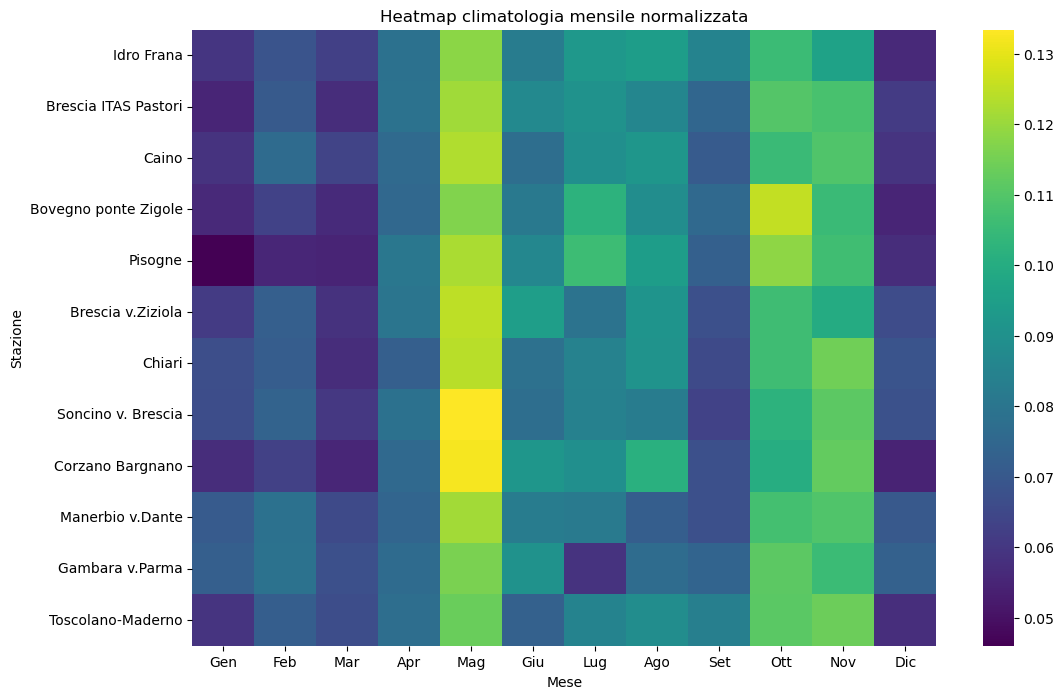

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

clim_norm = clim_df.div(clim_df.sum(axis=1), axis=0)

plt.figure(figsize=(12,8))
sns.heatmap(clim_norm, cmap="viridis")
plt.title("Heatmap climatologia mensile normalizzata")
plt.xlabel("Mese")
plt.ylabel("Stazione")
plt.show()


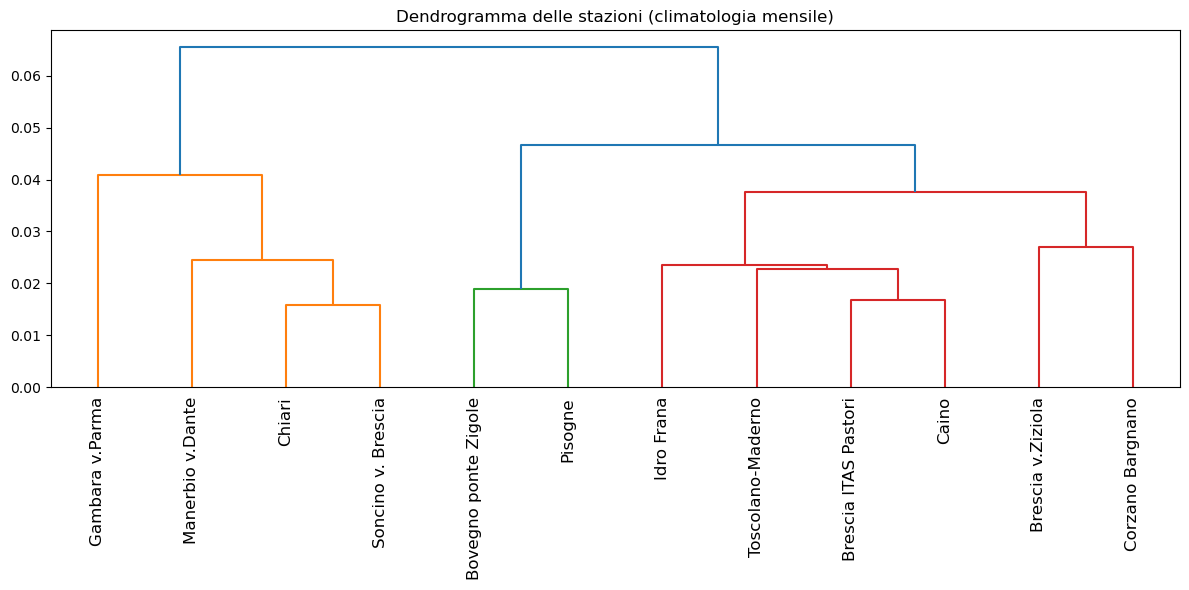

In [41]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(clim_norm.values, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z, labels=clim_norm.index, leaf_rotation=90)
plt.title("Dendrogramma delle stazioni (climatologia mensile)")
plt.tight_layout()
plt.show()


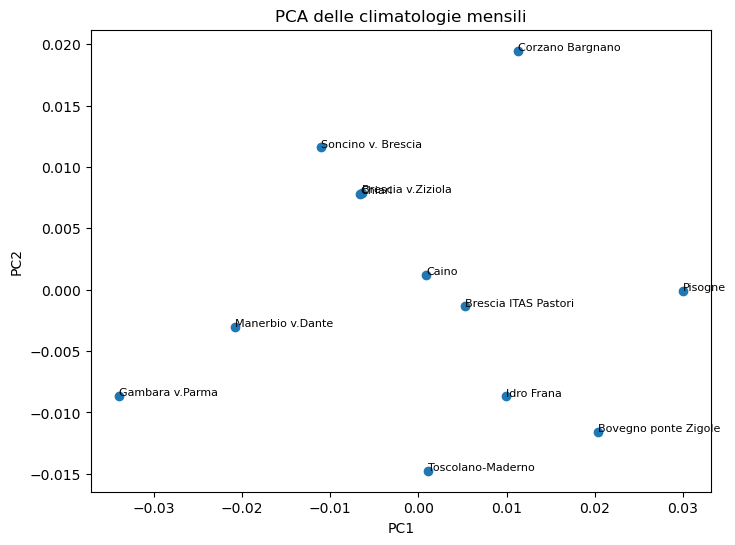

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(clim_norm.values)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, st in enumerate(clim_norm.index):
    plt.text(X_pca[i,0], X_pca[i,1], st, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA delle climatologie mensili")
plt.show()


In [44]:
# Carichi di ciascun mese su PC1 e PC2
loadings = pca.components_.T  # shape: (mesi, n_components)
df_loadings = pd.DataFrame(loadings, index=clim_norm.columns, columns=['PC1','PC2'])
print(df_loadings)


          PC1       PC2
Gen -0.395724  0.009834
Feb -0.358572 -0.087052
Mar -0.179929 -0.232481
Apr  0.045174 -0.009797
Mag  0.010600  0.557267
Giu -0.018398  0.226300
Lug  0.639091 -0.010606
Ago  0.344644  0.286887
Set  0.118422 -0.527711
Ott  0.165600 -0.433059
Nov -0.039661  0.153199
Dic -0.331248  0.067218


In [45]:
import plotly.graph_objects as go

fig = go.Figure()

for stazione in clim_norm.index:
    fig.add_trace(
        go.Scatter(
            x=mesi,
            y=clim_norm.loc[stazione],
            mode='lines',
            name=stazione,
            hovertemplate="<b>Stazione:</b> %{text}<br>Mese: %{x}<br>Frazione: %{y:.2f}<extra></extra>",
            text=[stazione]*12  # serve per far vedere il nome stazione nell'hover
        )
    )

fig.update_layout(
    title="Climatologie mensili normalizzate (tutte le stazioni)",
    xaxis_title="Mese",
    yaxis_title="Frazione della pioggia annua",
    hovermode="closest",
    legend=dict(title="Stazioni", font=dict(size=10))
)

fig.show()


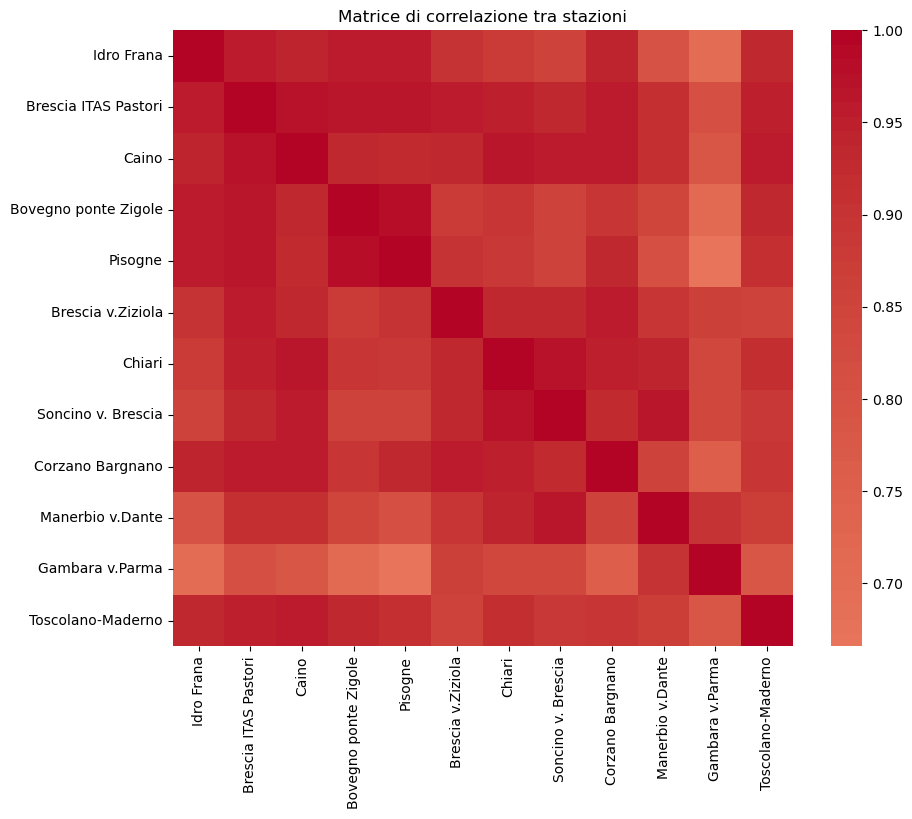

In [46]:
corr = clim_norm.T.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra stazioni")
plt.show()


In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

inizio = pd.Timestamp("2012-08-01")
fine   = pd.Timestamp("2025-08-31 23:59")

# Lista delle stagioni
stagioni_labels = ['Inverno','Primavera','Estate','Autunno']

# DataFrame lungo per accumuli stagionali
df_stagioni_cum = []

for stazione, df in serie_stazioni.items():
    # filtro stazioni con serie completa
    if df["Data_Ora"].min() > inizio or df["Data_Ora"].max() < fine:
        continue

    df_sel = df[(df["Data_Ora"]>=inizio) & (df["Data_Ora"]<=fine)].copy()
    df_sel = df_sel.dropna(subset=["Valore_Cumulato"])
    if df_sel.empty:
        continue

    # anno e mese
    df_sel['Anno'] = df_sel['Data_Ora'].dt.year
    df_sel['Mese'] = df_sel['Data_Ora'].dt.month

    # Definisco le stagioni con Categorical
    df_sel['Stagione'] = pd.cut(df_sel['Mese'],
                                bins=[0,2,5,8,11,12],
                                labels=['Inverno','Primavera','Estate','Autunno','Inverno2'],
                                right=True,
                                include_lowest=True)
    # Riporto Inverno2 a Inverno
    df_sel['Stagione'] = df_sel['Stagione'].replace({'Inverno2':'Inverno'})
    df_sel['Stagione'] = pd.Categorical(df_sel['Stagione'],
                                        categories=stagioni_labels,
                                        ordered=True)

    # Cumulata stagionale per anno
    cum_stagionale = df_sel.groupby(['Anno','Stagione'])['Valore_Cumulato'].sum().reset_index()
    cum_stagionale['Stazione'] = stazione

    df_stagioni_cum.append(cum_stagionale)

df_stagioni_cum = pd.concat(df_stagioni_cum)
print("Shape df_stagioni_cum:", df_stagioni_cum.shape)
print("Stazioni valide:", df_stagioni_cum['Stazione'].nunique())


C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\2769570994.py:37: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\2769570994.py:43: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\2769570994.py:37: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

C:\Use

Shape df_stagioni_cum: (672, 4)
Stazioni valide: 12


C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\2769570994.py:37: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\2769570994.py:43: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\2769570994.py:37: FutureWarning:

The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.

C:\Use

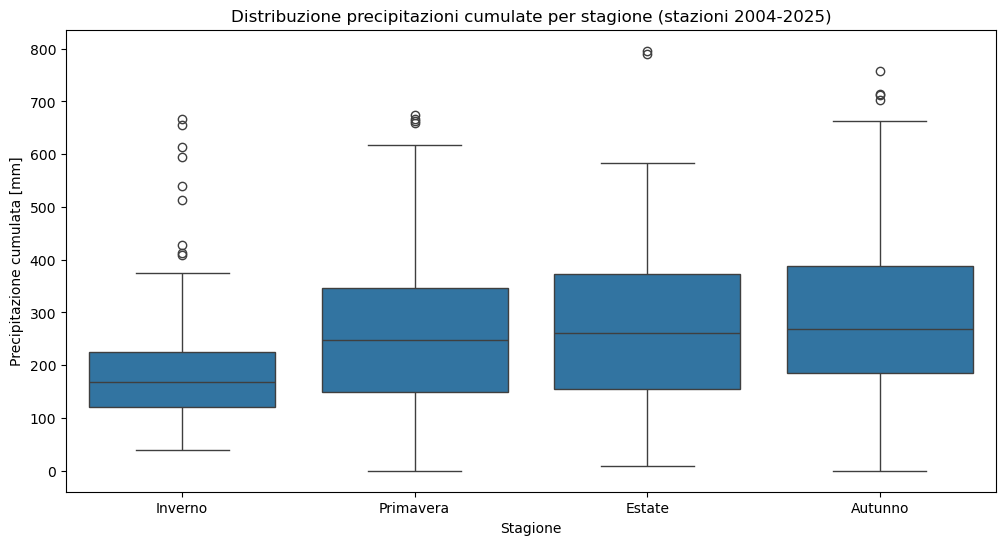

In [48]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_stagioni_cum, x='Stagione', y='Valore_Cumulato')
plt.title("Distribuzione precipitazioni cumulate per stagione (stazioni 2004-2025)")
plt.ylabel("Precipitazione cumulata [mm]")
plt.show()


C:\Users\michele.giurato\AppData\Local\Temp\ipykernel_27776\3919662273.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



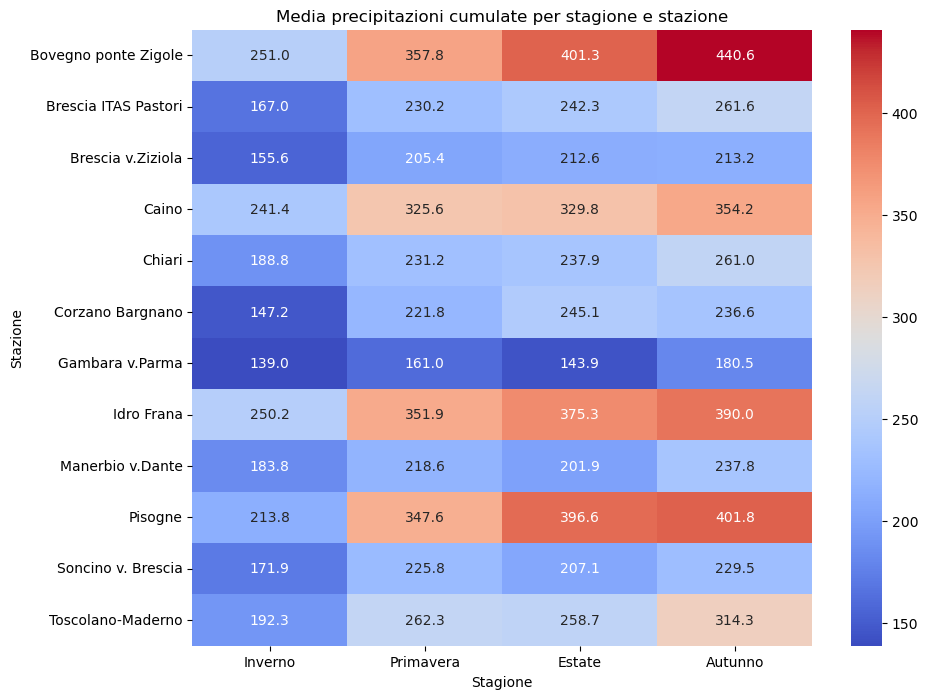

In [49]:
media_stagionale = df_stagioni_cum.groupby(['Stazione','Stagione'])['Valore_Cumulato'].mean().unstack()
plt.figure(figsize=(10,8))
sns.heatmap(media_stagionale, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Media precipitazioni cumulate per stagione e stazione")
plt.show()


In [50]:
fig = go.Figure()

for stazione in media_stagionale.index:
    fig.add_trace(
        go.Scatter(
            x=media_stagionale.columns,
            y=media_stagionale.loc[stazione],
            mode='lines+markers',
            name=stazione,
            hovertemplate="<b>%{text}</b><br>Stagione: %{x}<br>Cumulata media: %{y:.2f} mm<extra></extra>",
            text=[stazione]*len(media_stagionale.columns)
        )
    )

fig.update_layout(title="Precipitazioni cumulate medie per stagione (stazioni 2004-2025)",
                  xaxis_title="Stagione",
                  yaxis_title="Precipitazione cumulata media [mm]",
                  hovermode="closest")
fig.show()


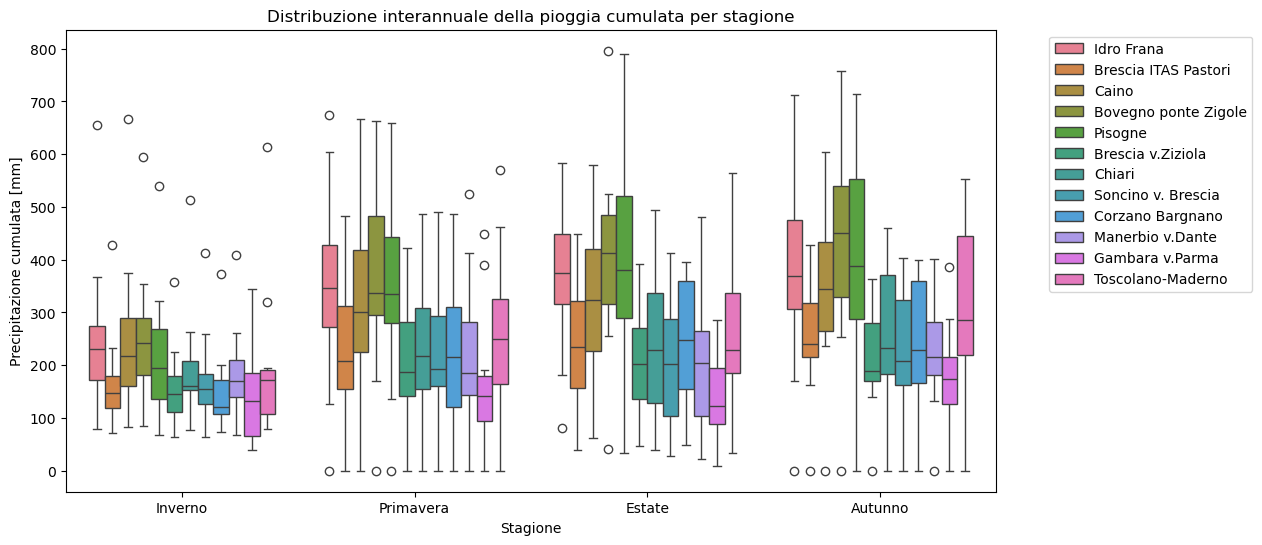

In [51]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_stagioni_cum, x='Stagione', y='Valore_Cumulato', hue='Stazione')
plt.title("Distribuzione interannuale della pioggia cumulata per stagione")
plt.ylabel("Precipitazione cumulata [mm]")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()
